In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv("E:\customer_shopping_behavior.csv")

<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:1: SyntaxWarning: invalid escape sequence '\c'
C:\Users\solom\AppData\Local\Temp\ipykernel_19352\783667418.py:1: SyntaxWarning: invalid escape sequence '\c'
  data = pd.read_csv("E:\customer_shopping_behavior.csv")


INITIAL EXPLORATORY ANALYSIS ABOUT THE DATA

In [4]:
data.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [6]:
data.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3863.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750065,25.351538
std,1125.977353,15.207589,23.685392,0.716983,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [7]:
data.describe(include='object')

,Gender,Item Purchased,Category,Location,Size,Color,Season,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Payment Method,Frequency of Purchases
count,3900,3900,3900,3900,3900,3900,3900,3900,3900,3900,3900,3900,3900
unique,2,25,4,50,4,25,4,2,6,2,2,6,7
top,Male,Blouse,Clothing,Montana,M,Olive,Spring,No,Free Shipping,No,No,PayPal,Every 3 Months
freq,2652,171,1737,96,1755,177,999,2847,675,2223,2223,677,584


array([[<Axes: title={'center': 'Customer ID'}>,
        <Axes: title={'center': 'Age'}>],
       [<Axes: title={'center': 'Purchase Amount (USD)'}>,
        <Axes: title={'center': 'Review Rating'}>],
       [<Axes: title={'center': 'Previous Purchases'}>, <Axes: >]],
      dtype=object)

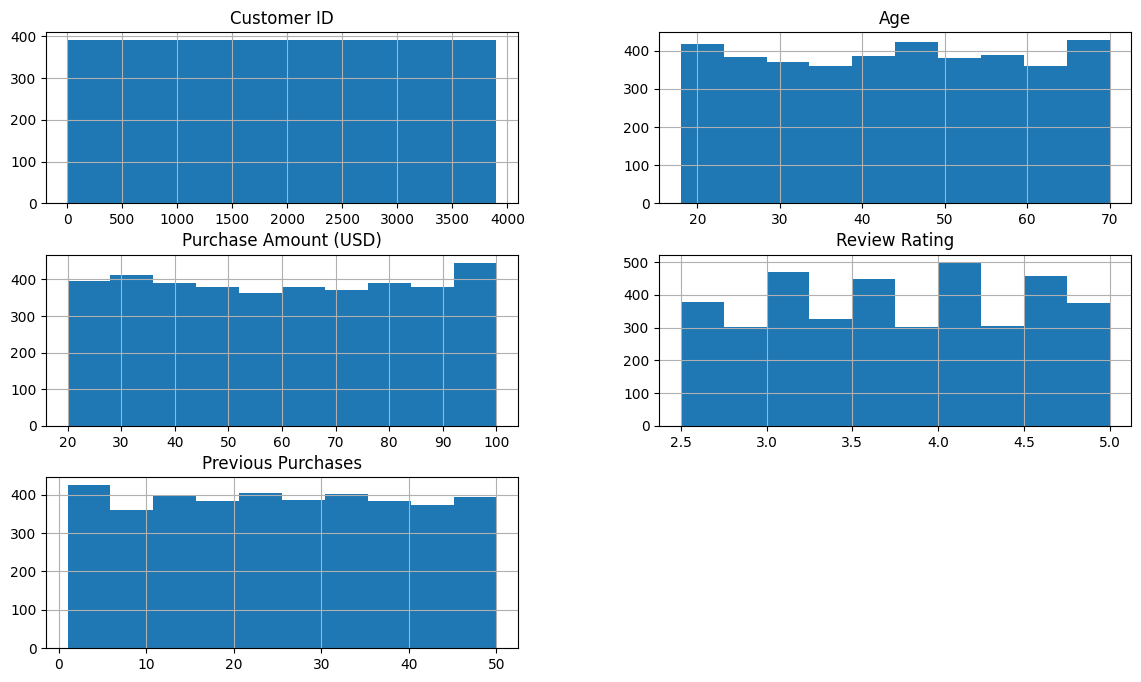

In [8]:
data.hist(figsize=(14,8))

In [9]:
data.isna().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

FILL IN FOR THE REVIEW RATING WITH THE RESPECTIVE MEDIAN VALUES

In [10]:
data['Review Rating'] = data.groupby('Category')['Review Rating'].transform(lambda x: x.fillna(x.median()))

In [11]:
data.isna().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

CHANGE COLUMN NAMES INTO SMALL LETTERS SPACED WITH _

In [12]:
data.columns = data.columns.str.lower()
data.columns = data.columns.str.replace(' ', '_')
data = data.rename(columns={'purchase_amount_(usd)': 'purchase_amount'})

In [13]:
data.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='object')

CREATING SOME COLUMNS

In [14]:
#create age-group column

lables = ['Young Adult', 'Adult', 'Middle-aged', 'Senior']
data['age-group'] = pd.qcut(data['age'], q=4, labels= lables)

In [15]:
data[['age', 'age-group']].head(10)

,age,age-group
0,55,Middle-aged
1,19,Young Adult
2,50,Middle-aged
3,21,Young Adult
4,45,Middle-aged
5,46,Middle-aged
6,63,Senior
7,27,Young Adult
8,26,Young Adult
9,57,Middle-aged


In [16]:
# Create column purchase_frequency_days

data['frequency_of_purchases'].head()

frequency_mapping = {
    'Fortnightly': 14,
    'Weekly': 7,
    'Annually': 365,
    'Quarterly': 90,
    'Bi-Weekly': 14,
    'Monthly': 30 ,
    'Every 3 Months': 90
}

data['purchase_frequency_days'] = data['frequency_of_purchases'].map(frequency_mapping)


In [17]:
data[['frequency_of_purchases', 'purchase_frequency_days']].head(10)

,frequency_of_purchases,purchase_frequency_days
0,Fortnightly,14
1,Fortnightly,14
2,Weekly,7
3,Weekly,7
4,Annually,365
5,Weekly,7
6,Quarterly,90
7,Weekly,7
8,Annually,365
9,Quarterly,90


In [18]:
# checking for the similarity between the discount_applied and promo_code_used columns
data[['discount_applied', 'promo_code_used']].head(10)


,discount_applied,promo_code_used
0,Yes,Yes
1,Yes,Yes
2,Yes,Yes
3,Yes,Yes
4,Yes,Yes
5,Yes,Yes
6,Yes,Yes
7,Yes,Yes
8,Yes,Yes
9,Yes,Yes


In [19]:
(data['discount_applied'] == data['promo_code_used'] ).all()

np.True_

In [20]:
#Since the discount applied and the promo code used is the same data, we drop the promo code used column
data = data.drop('promo_code_used', axis = 1)

In [21]:
data.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'age-group', 'purchase_frequency_days'],
      dtype='object')

FINALLY MOVE THE DATASET TO SQL SERVER

**Connecting to SQL Server**

In [25]:
pip install pyodbc sqlalchemy

   ---------------------------------------- 0.0/70.1 kB ? eta -:--:--
   ----- ---------------------------------- 10.2/70.1 kB ? eta -:--:--
   ----------------- ---------------------- 30.7/70.1 kB 435.7 kB/s eta 0:00:01
   ----------------------- ---------------- 41.0/70.1 kB 326.8 kB/s eta 0:00:01
   ---------------------------------------- 70.1/70.1 kB 424.8 kB/s eta 0:00:00
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   - -------------------------------------- 0.1/2.1 MB 3.4 MB/s eta 0:00:01
   -- ------------------------------------- 0.1/2.1 MB 2.2 MB/s eta 0:00:01
   -- ------------------------------------- 0.1/2.1 MB 1.0 MB/s eta 0:00:02
   ---- ----------------------------------- 0.2/2.1 MB 1.4 MB/s eta 0:00:02
   ------ --------------------------------- 0.3/2.1 MB 1.8 MB/s eta 0:00:02
   -------- ------------------------------- 0.5/2.1 MB 1.8 MB/s eta 0:00:01
   ----------- ---------------------------- 0.6/2.1 MB 1.8 MB/s eta 0:00:01
   ------------ --


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus

#SQL Server connection
username = "GOD_IS_NOT_DEAD/solom"
password = ""
host = "(local)"
port = ""
database = "customer_behaviour"

# Note: requires Microsoft ODBC Driver installed separately on your machine
driver = quote_plus("ODBC Driver 17 for SQL Server")
engine = create_engine(f"mssql+pyodbc://{username}:{password}@{host},{port}/{database}?driver={driver}")

# Write DataFrame to SQL Server
data.to_sql("customer", engine, if_exists="replace", index=False)

# Read back sample (SQL Server uses TOP instead of LIMIT)
pd.read_sql("SELECT TOP 5 * FROM customer;", engine)

InterfaceError: (pyodbc.InterfaceError) ('28000', '[28000] [Microsoft][ODBC Driver 17 for SQL Server][SQL Server]Login failed for user \'GOD_IS_NOT_DEAD\\solom\'. (18456) (SQLDriverConnect); [28000] [Microsoft][ODBC Driver 17 for SQL Server][SQL Server]Cannot open database "solom:@(local),/customer_behaviour" requested by the login. The login failed. (4060); [28000] [Microsoft][ODBC Driver 17 for SQL Server][SQL Server]Login failed for user \'GOD_IS_NOT_DEAD\\solom\'. (18456); [28000] [Microsoft][ODBC Driver 17 for SQL Server][SQL Server]Cannot open database "solom:@(local),/customer_behaviour" requested by the login. The login failed. (4060)')
(Background on this error at: https://sqlalche.me/e/20/rvf5)

In [24]:
#Exporting the data into a CSV file

output_filename = 'customer_shopping_behavior_processed.csv'
data.to_csv(output_filename, index=False)
print(f"Data successfully exported to {output_filename}")



Data successfully exported to customer_shopping_behavior_processed.csv


In [25]:
from IPython.display import FileLink

FileLink("customer_shopping_behavior_processed.csv")

C:\Users\solom\customer_shopping_behavior_processed.csv